In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

In [31]:
# Si tu pars de ta fonction existante :
from data_processing import build_processed_dataframe

DEFAULT_TEXT_COLUMNS = [
    "id",
    "text",
    "date",
    "contexte-tour",
    "departement",
    "identifiant de circonscription",
    "titulaire-sexe",
    "titulaire-mandat-en-cours",
    "titulaire-mandat-passe",
    "titulaire-soutien",
]

df = build_processed_dataframe(
    base_dir="data",
    candidate_file="archelect_search.csv",
    selected_columns=DEFAULT_TEXT_COLUMNS,
    soutien_mapping_csv="data/partis_correspondance.csv",
    mandat_mapping_csv="data/mandats_correspondance.csv",
)

In [32]:
df["n_chars"] = df["text"].str.len()
df["n_words_raw"] = df["text"].str.split().str.len()

print("Nombre de textes :", len(df))
print("Nombre de mots total :", df["n_words_raw"].sum())
print("Longueur moyenne :", round(df["n_words_raw"].mean(), 1))
print("Longueur médiane :", round(df["n_words_raw"].median(), 1))

df[["n_chars", "n_words_raw"]].describe()

Nombre de textes : 21167
Nombre de mots total : 14643498
Longueur moyenne : 691.8
Longueur médiane : 618.0


,n_chars,n_words_raw
count,21167.000000,21167.000000
mean,4370.280626,691.807909
std,2287.055580,363.217882
min,84.000000,10.000000
25%,2680.000000,422.000000
50%,3928.000000,618.000000
75%,5661.000000,896.000000
max,24916.000000,3919.000000


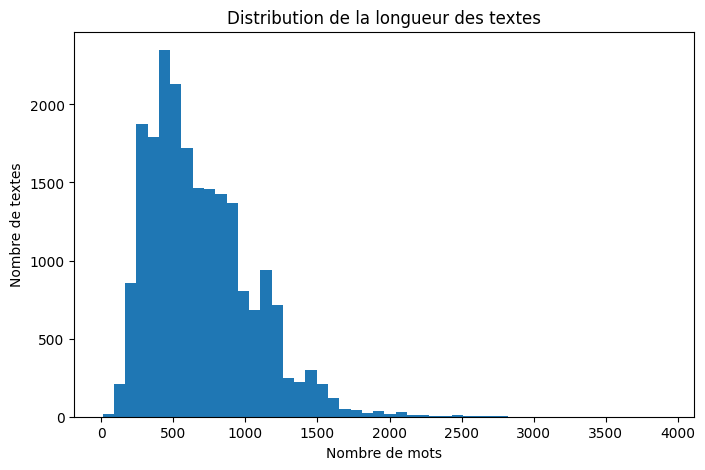

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(df["n_words_raw"], bins=50)
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de textes")
plt.title("Distribution de la longueur des textes")
plt.show()

In [34]:
STOPWORDS = [x.strip() for x in open('data/stop_words.txt').readlines()]

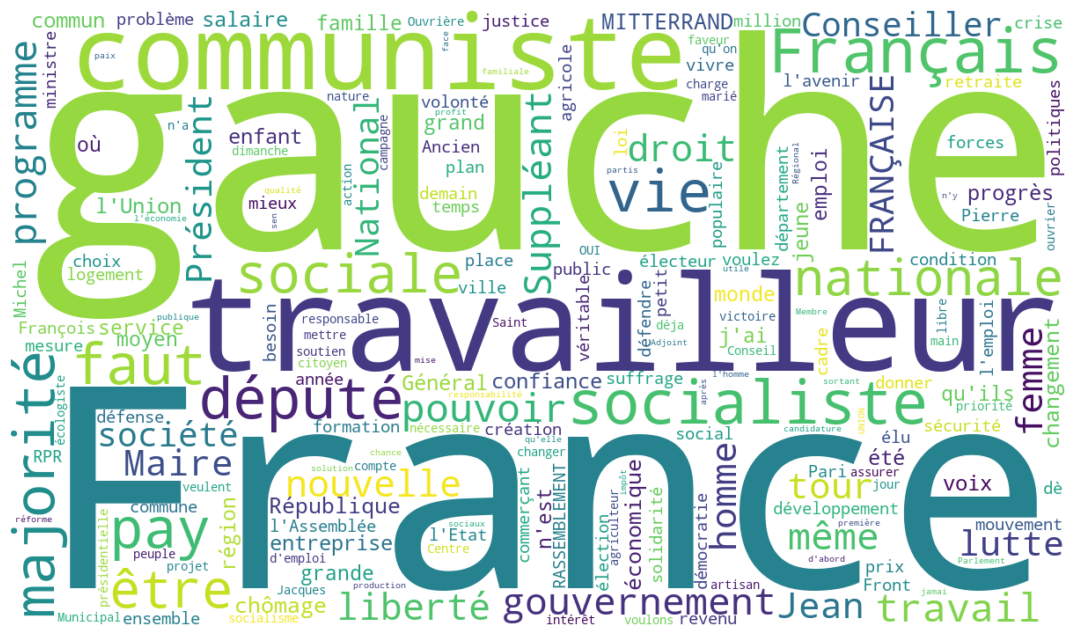

In [35]:
all_text = " ".join(df["text"])

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    stopwords=STOPWORDS,
    max_words=200,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [36]:
count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=list(STOPWORDS),
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÖØ-öø-ÿ][a-zA-ZÀ-ÖØ-öø-ÿ'-]{2,}\b",
    max_features=5000,
    min_df=2
)

X_counts = count_vectorizer.fit_transform(df["text"])
terms = count_vectorizer.get_feature_names_out()

word_counts = np.asarray(X_counts.sum(axis=0)).ravel()

freq_df = pd.DataFrame({
    "term": terms,
    "count": word_counts
}).sort_values("count", ascending=False)

freq_df.head(50)

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celle-lã', 'celles-lã', 'celui-lã', 'celã', 'cembre', 'ceux-lã', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'elle-', 'elles-', 'eux-', 'exceptã', 'faã', 'gislatives', 'holã', 'huitiã', 'lections', 'lui-', 'majoritã', 'malgrã', 'mement', 'moi-', 'neuviã', 'nommã', 'nous-', 'ohã', 'ollã', 'olã', 'onziã', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quant-ã', 'quatriã', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'soi-', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'toi-', 'tre', 'troisiã', 'trã', 'voilã', 'votã', 'vous-', 'vrier'] not in stop_words.
  warnings.wa

,term,count
1921,gauche,39968
1852,france,37665
4598,travailleurs,30682
1860,français,29498
4741,vie,26956
2759,majorité,25580
1737,faut,25236
3272,pays,24768
4591,travail,21364
3060,nationale,20352


In [37]:
bigram_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=list(STOPWORDS),
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÖØ-öø-ÿ][a-zA-ZÀ-ÖØ-öø-ÿ'-]{2,}\b",
    ngram_range=(2, 2),
    max_features=5000,
    min_df=2
)

X_bigrams = bigram_vectorizer.fit_transform(df["text"])
bigram_terms = bigram_vectorizer.get_feature_names_out()

bigram_counts = np.asarray(X_bigrams.sum(axis=0)).ravel()

bigram_freq_df = pd.DataFrame({
    "bigram": bigram_terms,
    "count": bigram_counts
}).sort_values("count", ascending=False)

bigram_freq_df.head(50)

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celle-lã', 'celles-lã', 'celui-lã', 'celã', 'cembre', 'ceux-lã', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'elle-', 'elles-', 'eux-', 'exceptã', 'faã', 'gislatives', 'holã', 'huitiã', 'lections', 'lui-', 'majoritã', 'malgrã', 'mement', 'moi-', 'neuviã', 'nommã', 'nous-', 'ohã', 'ollã', 'olã', 'onziã', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quant-ã', 'quatriã', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'soi-', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'toi-', 'tre', 'troisiã', 'trã', 'voilã', 'votã', 'vous-', 'vrier'] not in stop_words.
  warnings.wa

,bigram,count
3423,programme commun,9620
2136,l'assemblée nationale,7907
1670,front national,7205
687,conseiller général,6720
1656,françois mitterrand,6637
606,communiste français,5199
3977,république française,5044
688,conseiller municipal,4861
3563,président république,4753
4921,électrices électeurs,4159


In [140]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import strip_accents_unicode

# ------------------------------------------------------------
# 1. Choose the words or expressions to track
# ------------------------------------------------------------

target_terms = [
    "majorite",
    "president",
    "nucléaire",
    "travail",
    "armée", 
    "chasse"
    ]

# ------------------------------------------------------------
# 2. Prepare year variable
# ------------------------------------------------------------

df_terms = df.copy()

# Try to extract the year from the date column
df_terms["year"] = pd.to_datetime(df_terms["date"], errors="coerce").dt.year

# Fallback if the date column is not in a standard date format
missing_year = df_terms["year"].isna()
df_terms.loc[missing_year, "year"] = (
    df_terms.loc[missing_year, "date"]
    .astype(str)
    .str.extract(r"(19\d{2}|20\d{2})")[0]
    .astype(float)
)

df_terms["year"] = df_terms["year"].astype(int)

# ------------------------------------------------------------
# 3. Normalize target terms
# ------------------------------------------------------------

def normalize_term(term):
    term = term.lower().strip()
    term = strip_accents_unicode(term)
    term = re.sub(r"\s+", " ", term)
    return term

terms_norm = [normalize_term(term) for term in target_terms]
terms_norm = list(dict.fromkeys(terms_norm))  # remove duplicates while keeping order

# Keep a mapping to display nicer labels
term_labels = {
    normalize_term(term): term
    for term in target_terms
}

max_ngram = max(len(term.split()) for term in terms_norm)

# ------------------------------------------------------------
# 4. Compute TF-IDF scores
# ------------------------------------------------------------

vectorizer_terms = TfidfVectorizer(
    vocabulary=terms_norm,
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, max_ngram)
)

X_tfidf = vectorizer_terms.fit_transform(df_terms["text"].astype(str))

tfidf_doc = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer_terms.get_feature_names_out()
)

tfidf_doc["titulaire-soutien-categorie"] = df_terms["titulaire-soutien-categorie"].values
tfidf_doc["year"] = df_terms["year"].values

# Average TF-IDF score by political group and year
tfidf_by_group_year = (
    tfidf_doc
    .groupby(["titulaire-soutien-categorie", "year"])[terms_norm]
    .mean()
    .reset_index()
)

# Long format for plotting
tfidf_long = tfidf_by_group_year.melt(
    id_vars=["titulaire-soutien-categorie", "year"],
    value_vars=terms_norm,
    var_name="term",
    value_name="tfidf"
)

tfidf_long["term_label"] = tfidf_long["term"].map(term_labels)

tfidf_long.head()

,titulaire-soutien-categorie,year,term,tfidf,term_label
0,Action spécifique,1978,majorite,0.025052,majorite
1,Action spécifique,1993,majorite,0.080853,majorite
2,Centre,1973,majorite,0.389450,majorite
3,Centre,1978,majorite,0.613491,majorite
4,Centre,1981,majorite,0.328550,majorite


In [141]:
def plot_term_left_right_bars(term, data=tfidf_long):
    term_norm = normalize_term(term)

    # Keep only the selected term
    plot_data = data[data["term"] == term_norm].copy()

    if plot_data.empty:
        print(f"Term not found: {term}")
        return

    # Define political blocs
    left_groups = [
        "Extrême-gauche",
        "Gauche",
        "Centre gauche"
    ]

    right_groups = [
        "Centre-droit",
        "Droite libérale",
        "Droite gaulliste"
    ]

    # Create a new variable with the two blocs
    plot_data["bloc"] = np.nan

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(left_groups),
        "bloc"
    ] = "Ensemble gauche"

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(right_groups),
        "bloc"
    ] = "Ensemble droite"

    # Keep only left and right blocs
    plot_data = plot_data.dropna(subset=["bloc"])

    if plot_data.empty:
        print("No data found for the selected left/right blocs.")
        return

    # Aggregate by year and bloc
    grouped = (
        plot_data
        .groupby(["year", "bloc"])["tfidf"]
        .mean()
        .reset_index()
    )

    # Pivot to have one column per bloc
    pivot = grouped.pivot(
        index="year",
        columns="bloc",
        values="tfidf"
    ).fillna(0)

    # Ensure both columns exist
    for col in ["Ensemble gauche", "Ensemble droite"]:
        if col not in pivot.columns:
            pivot[col] = 0

    pivot = pivot[["Ensemble gauche", "Ensemble droite"]]
    pivot = pivot.sort_index()

    # Plot side-by-side bar chart
    years = pivot.index.astype(int)
    x = np.arange(len(years))
    width = 0.35

    plt.figure(figsize=(12, 6))

    plt.bar(
        x - width / 2,
        pivot["Ensemble gauche"],
        width,
        label="Left-wing",
        color = "red"
    )

    plt.bar(
        x + width / 2,
        pivot["Ensemble droite"],
        width,
        label="Right-wing",
        color = "blue"
    )

    plt.xlabel("Year")
    plt.ylabel("Mean TF-IDF score")

    plt.xticks(x, years)
    plt.legend(title="Political bloc")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

C:\Users\mathi\AppData\Local\Temp\ipykernel_24500\2375816992.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ensemble gauche' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  plot_data.loc[


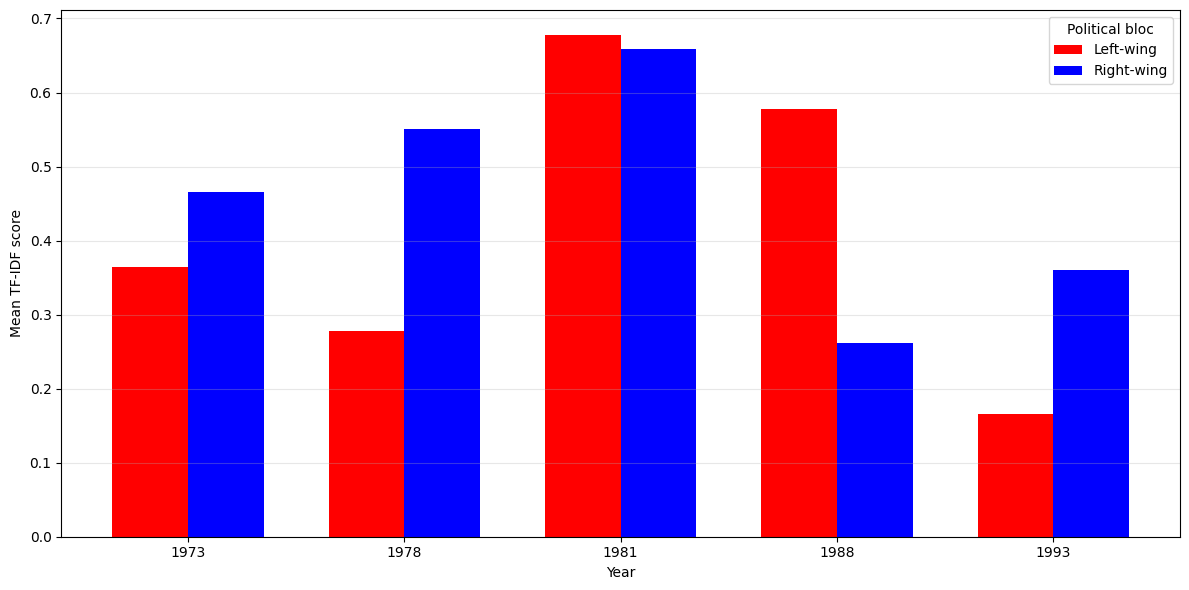

C:\Users\mathi\AppData\Local\Temp\ipykernel_24500\2375816992.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ensemble gauche' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  plot_data.loc[


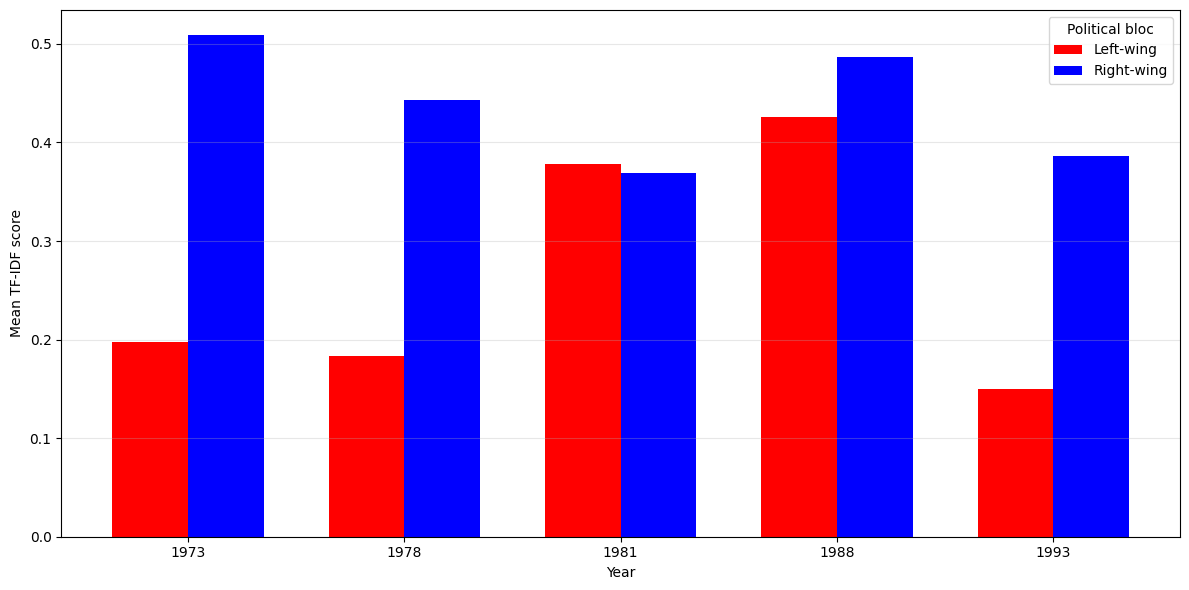

C:\Users\mathi\AppData\Local\Temp\ipykernel_24500\2375816992.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ensemble gauche' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  plot_data.loc[


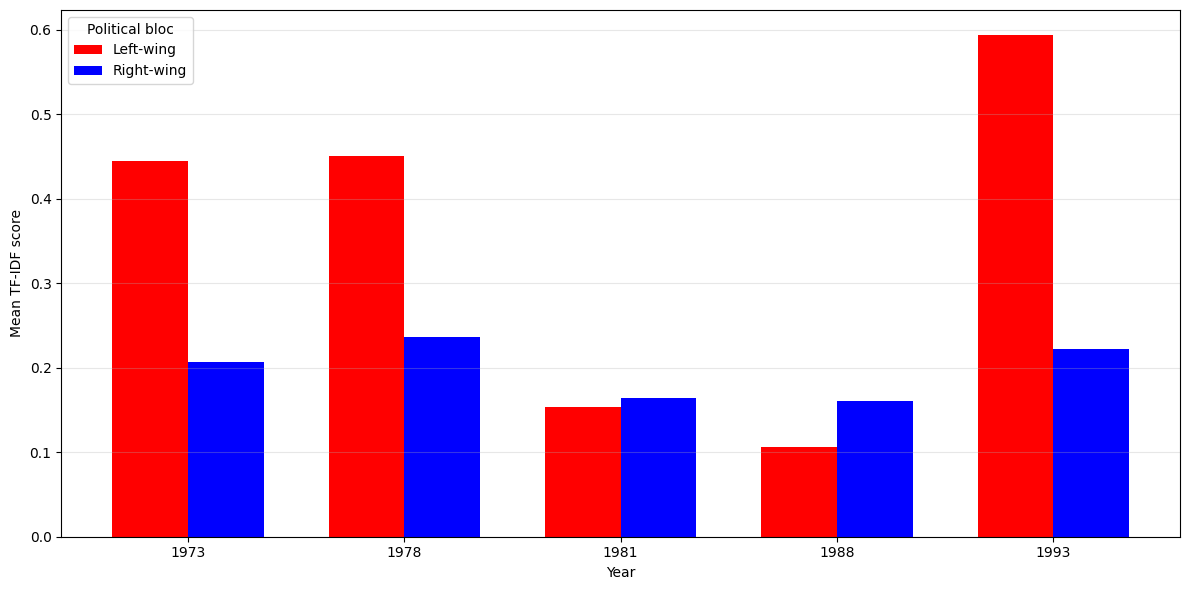

C:\Users\mathi\AppData\Local\Temp\ipykernel_24500\2375816992.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ensemble gauche' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  plot_data.loc[


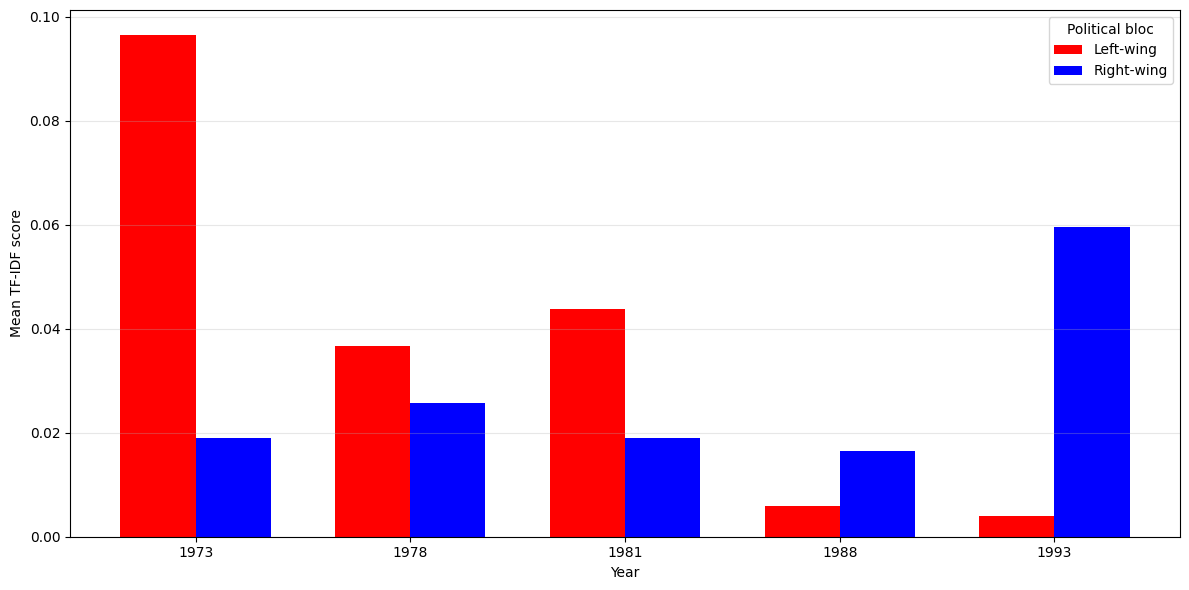

In [142]:
L = [
    "majorite",
    "president",
    "travail",
    "armée",
    ]
for l in L:
    plot_term_left_right_bars(l)

In [152]:
def plot_term_left_right_ecologist_bars(term, data=tfidf_long):
    term_norm = normalize_term(term)

    # Keep only the selected term
    plot_data = data[data["term"] == term_norm].copy()

    if plot_data.empty:
        print(f"Term not found: {term}")
        return

    # Define political blocs
    left_groups = [
        "Extrême-gauche",
        "Gauche",
        "Centre gauche"
    ]

    right_groups = [
        "Centre-droit",
        "Droite libérale",
        "Droite gaulliste"
    ]

    ecologist_groups = [
        "Ecologiste",
    ]

    # Create a new variable with the blocs
    plot_data["bloc"] = np.nan

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(left_groups),
        "bloc"
    ] = "Ensemble gauche"

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(right_groups),
        "bloc"
    ] = "Ensemble droite"

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(ecologist_groups),
        "bloc"
    ] = "Écologistes"

    # Keep only the selected blocs
    plot_data = plot_data.dropna(subset=["bloc"])

    if plot_data.empty:
        print("No data found for the selected blocs.")
        return

    # Aggregate by year and bloc
    grouped = (
        plot_data
        .groupby(["year", "bloc"])["tfidf"]
        .mean()
        .reset_index()
    )

    # Pivot to have one column per bloc
    pivot = grouped.pivot(
        index="year",
        columns="bloc",
        values="tfidf"
    ).fillna(0)

    # Ensure all columns exist
    bloc_order = ["Ensemble gauche", "Écologistes", "Ensemble droite"]

    for col in bloc_order:
        if col not in pivot.columns:
            pivot[col] = 0

    pivot = pivot[bloc_order]
    pivot = pivot.sort_index()

    # Plot side-by-side bar chart
    years = pivot.index.astype(int)
    x = np.arange(len(years))
    width = 0.25

    plt.figure(figsize=(12, 6))

    plt.bar(
        x - width,
        pivot["Ensemble gauche"],
        width,
        label="Ensemble gauche",
        color="red"
    )

    plt.bar(
        x,
        pivot["Écologistes"],
        width,
        label="Écologistes",
        color="green"
    )

    plt.bar(
        x + width,
        pivot["Ensemble droite"],
        width,
        label="Ensemble droite",
        color="blue"
    )

    plt.xlabel("Year")
    plt.ylabel("Mean TF-IDF score")

    plt.xticks(x, years)
    plt.legend(title="Political bloc")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

C:\Users\mathi\AppData\Local\Temp\ipykernel_24500\2676580880.py:31: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ensemble gauche' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  plot_data.loc[


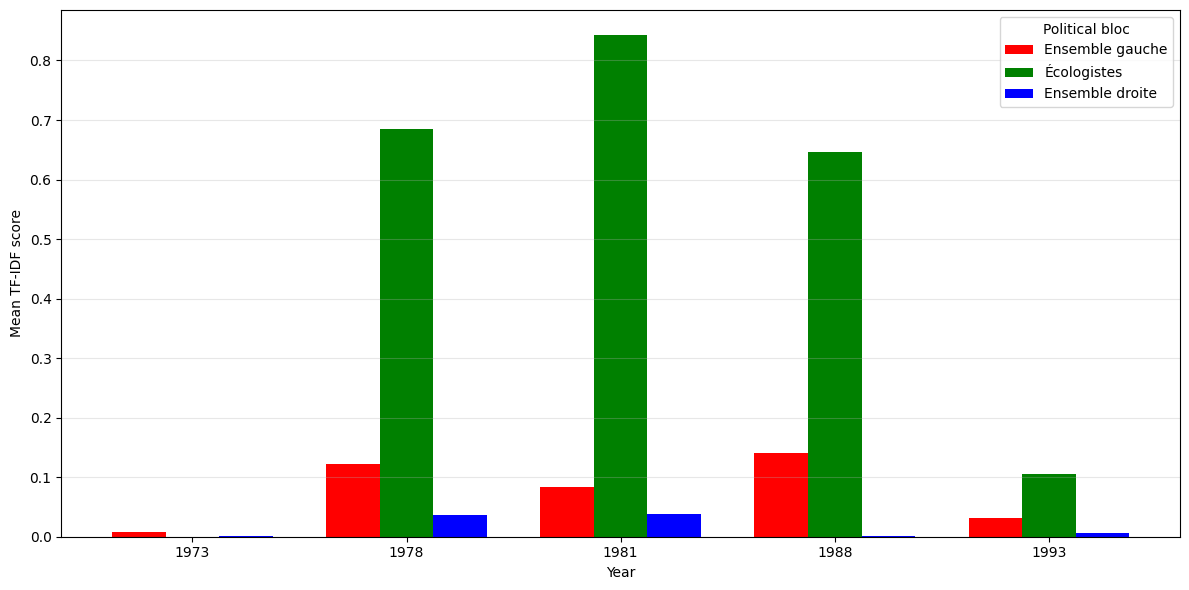

In [153]:
plot_term_left_right_ecologist_bars("nucléaire")

In [154]:
def plot_term_blocs_bars(term, data=tfidf_long):
    term_norm = normalize_term(term)

    # Keep only the selected term
    plot_data = data[data["term"] == term_norm].copy()

    if plot_data.empty:
        print(f"Term not found: {term}")
        return

    # Define political blocs
    left_groups = [
        "Extrême-gauche",
        "Gauche",
        "Centre gauche"
    ]

    right_groups = [
        "Centre-droit",
        "Droite libérale",
        "Droite gaulliste"
    ]

    ecologist_groups = [
        "Ecologiste"
    ]

    specific_interest_groups = [
        "Action spécifique"
    ]

    # Create a new variable with the blocs
    plot_data["bloc"] = np.nan

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(left_groups),
        "bloc"
    ] = "Ensemble gauche"

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(ecologist_groups),
        "bloc"
    ] = "Écologistes"

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(specific_interest_groups),
        "bloc"
    ] = "Intérêt spécifique"

    plot_data.loc[
        plot_data["titulaire-soutien-categorie"].isin(right_groups),
        "bloc"
    ] = "Ensemble droite"

    # Keep only the selected blocs
    plot_data = plot_data.dropna(subset=["bloc"])

    if plot_data.empty:
        print("No data found for the selected blocs.")
        return

    # Aggregate by year and bloc
    grouped = (
        plot_data
        .groupby(["year", "bloc"])["tfidf"]
        .mean()
        .reset_index()
    )

    # Pivot to have one column per bloc
    pivot = grouped.pivot(
        index="year",
        columns="bloc",
        values="tfidf"
    ).fillna(0)

    # Ensure all columns exist
    bloc_order = [
        "Ensemble gauche",
        "Écologistes",
        "Intérêt spécifique",
        "Ensemble droite"
    ]

    for col in bloc_order:
        if col not in pivot.columns:
            pivot[col] = 0

    pivot = pivot[bloc_order]
    pivot = pivot.sort_index()

    # Plot side-by-side bar chart
    years = pivot.index.astype(int)
    x = np.arange(len(years))
    width = 0.20

    plt.figure(figsize=(13, 6))

    plt.bar(
        x - 1.5 * width,
        pivot["Ensemble gauche"],
        width,
        label="Left-wing",
        color="red"
    )

    plt.bar(
        x - 0.5 * width,
        pivot["Écologistes"],
        width,
        label="Ecologist",
        color="green"
    )

    plt.bar(
        x + 0.5 * width,
        pivot["Intérêt spécifique"],
        width,
        label="Focus group",
        color="orange"
    )

    plt.bar(
        x + 1.5 * width,
        pivot["Ensemble droite"],
        width,
        label="Right-wing",
        color="blue"
    )

    plt.xlabel("Year")
    plt.ylabel("Mean TF-IDF score")

    plt.xticks(x, years)
    plt.legend(title="Political bloc")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

C:\Users\mathi\AppData\Local\Temp\ipykernel_24500\3475277686.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ensemble gauche' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  plot_data.loc[


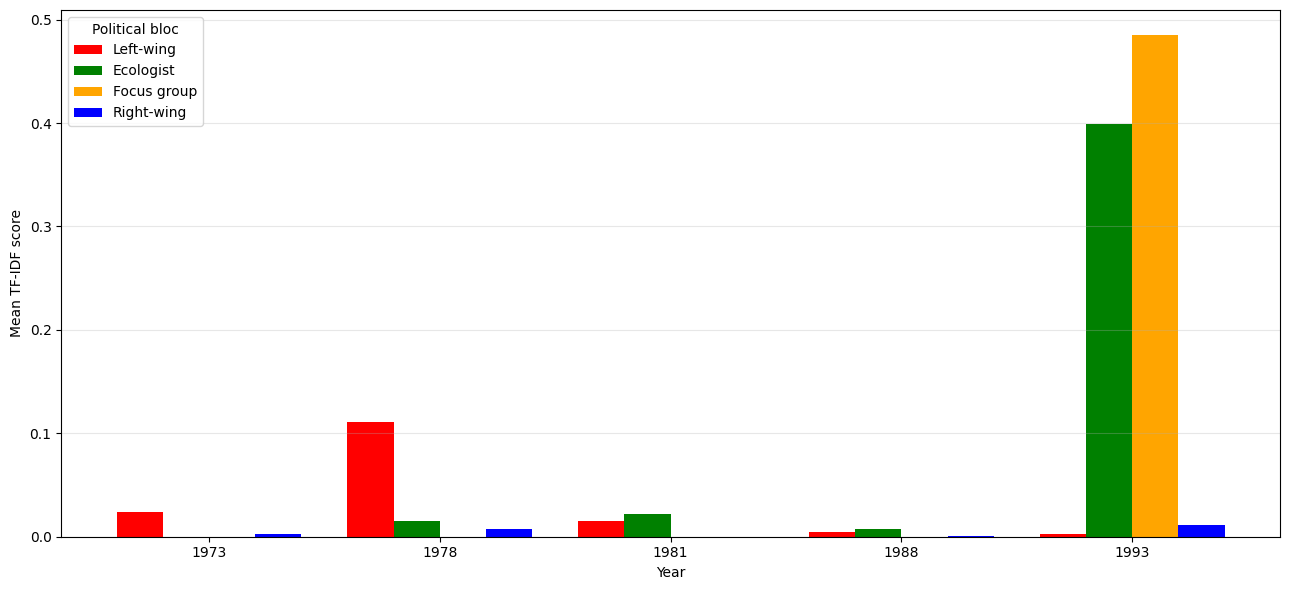

In [155]:
plot_term_blocs_bars("chasse")